In [ ]:
# Upgrade torchao to a compatible version for PEFT
# This is necessary because your current torchao version is too old for the peft library.
!pip install --upgrade torchao
print('torchao upgraded. Please restart the runtime if you continue to face issues.')

torchao upgraded. Please restart the runtime if you continue to face issues.


In [ ]:
'''import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"'''

In [ ]:
!pip install torch transformers peft trl

In [ ]:
!pip install bitsandbytes

In [ ]:
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

# Hyperparameter configurations

Model that is fine tuned is mistral AI. Mistral AI is known for beeing efficient and powerful. Other model to consider aree Llama-3 (computationally expensive), Phi-3

In [61]:
MODEL_ID = "black-forest-labs/FLUX.1-dev"  # Changed to a smaller model
OUTPUT_DIR = "./fine_tuned_llm"

# LoRA Hyperparameters
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = ["attn.to_q", "attn.to_k", "attn.to_v", "attn.to_out.0"]

# Training Hyperparameters
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 8  # Increased to reduce memory usage
LEARNING_RATE = 2e-4
MAX_STEPS = 100  # Adjust based on dataset size (or use num_train_epochs)

###LoRA Hyperparameters (for QLoRA fine-tuning):


LORA_R = 16 (Rank r): This is one of the most crucial LoRA parameters. It determines the rank of the low-rank matrices that are added to the pre-trained model's weight matrices. A higher r allows for more expressiveness and capacity to learn new information, but also increases the number of trainable parameters and VRAM usage. A lower r means fewer trainable parameters, making the fine-tuning more efficient but potentially less effective at capturing complex new patterns.

LORA_ALPHA = 32 (α): This parameter scales the learned low-rank updates. It's often set to 2 * LORA_R or a similar multiple. A higher alpha means the LoRA layers have a stronger influence on the original weights. It essentially controls the magnitude of the updates applied by the LoRA adapters.

LORA_DROPOUT = 0.05: This is a standard dropout rate applied to the LoRA layers during training. Dropout is a regularization technique that randomly sets a fraction of input units to 0 at each update during training, which helps prevent overfitting by encouraging the model to learn more robust features.

TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]: This specifies which parts (modules) of the pre-trained transformer model will have LoRA layers attached to them. In Large Language Models, q_proj, k_proj, v_proj (query, key, and value projection layers in attention mechanisms) and o_proj (output projection) are common targets. gate_proj, up_proj, down_proj refer to the feed-forward network's layers.

By selectively applying LoRA to these critical modules, you can efficiently fine-tune the model without modifying all its original weights.

###Training Hyperparameters:


BATCH_SIZE = 4 (per_device_train_batch_size): This is the number of training examples processed at once on each GPU. Smaller batch sizes often lead to better generalization but longer training times. For QLoRA, which is memory-efficient, you can often use larger batch sizes than full fine-tuning.

GRADIENT_ACCUMULATION_STEPS = 4: When memory is a constraint (even with QLoRA), you can simulate a larger effective batch size by accumulating gradients over several smaller batches. Here, an effective batch size of BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS = 4 * 4 = 16 is used. The model weights are updated only after processing GRADIENT_ACCUMULATION_STEPS batches.

LEARNING_RATE = 2e-4: This determines the step size at each iteration while moving towards a minimum of the loss function. It's a critical hyperparameter; too high, and the model might overshoot the minimum; too low, and training could be very slow or get stuck in a local minimum. For QLoRA, a slightly lower learning rate than full fine-tuning is often recommended.

MAX_STEPS = 100: This defines the total number of update steps (batches after gradient accumulation) the trainer will perform during the fine-tuning process. You mentioned adjusting this based on dataset size or using num_train_epochs, which is a good practice. For a small dataset or initial experimentation, 100 steps is a reasonable starting point.

In [ ]:
from google.colab import userdata
import os

# Access your Hugging Face token from Colab Secrets
hf_token = userdata.get('HF_TOKEN')

# Set it as an environment variable, which many Hugging Face libraries will automatically pick up
os.environ['HF_TOKEN'] = hf_token

print("Hugging Face token loaded and set as environment variable.")

Hugging Face token loaded and set as environment variable.


# Loading dataset

dataset derived from hugging face is tatsu-lab/alpaca which has been surpassed with more recent dataseet such as databricks/databricks-dolly-15k and OpenAssistant/oasst1.

Production level performance involve using more comprehensive dataset that has a higher quality (less noisy), greater diversity (wider range of instruction) and larger scale.

In [ ]:
# Load tokenizer before using it in format_prompts
#from transformers import AutoTokenizer
from transformers import CLIPTokenizer, T5TokenizerFast

tokenizer_one = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
tokenizer_two = T5TokenizerFast.from_pretrained(MODEL_ID, subfolder="tokenizer_2")


print("FLUX tokenizers loaded successfully!")

tokenizer_config.json:   0%|          | 0.00/705 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer_2/spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

FLUX tokenizers loaded successfully!


In [ ]:
# ==========================================
# 2. LOAD DATASET
# ==========================================
# Loading a sample instruction dataset from Hugging Face
# Ensure your data has a column with formatted text, or use a formatting function

#DATASET_ID = "multimodalart/faces-cleaned"

train_stream = load_dataset("common-canvas/commoncatalog-cc-by", split="train", streaming=True) # Using first 1000 rows for demonstration

train_dataset = train_stream.take(1000)
eval_dataset = train_stream.skip(1000).take(100)

sample_item = next(iter(train_dataset))
print("Columns/keys from the dataset:", sample_item.keys())

README.md:   0%|          | 0.00/5.52k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/5573 [00:00<?, ?it/s]

Columns/keys from the dataset: dict_keys(['jpg', 'blip2_caption', 'caption', 'licensename', 'licenseurl', 'width', 'height', 'original_width', 'original_height', 'photoid', 'uid', 'unickname', 'datetaken', 'dateuploaded', 'capturedevice', 'title', 'usertags', 'machinetags', 'longitude', 'latitude', 'accuracy', 'pageurl', 'downloadurl', 'serverid', 'farmid', 'secret', 'secretoriginal', 'ext', 'url', 'key', 'status', 'error_message', 'exif', 'sha256', 'description'])


# Loading Tokenizer

In [ ]:
# ==========================================
# 3. LOAD TOKENIZER AND QUANTIZED MODEL
# ==========================================
import torch
from diffusers import FluxPipeline

# 1. Correct Model ID reference
MODEL_ID = "black-forest-labs/FLUX.1-dev"

# 2. Load the correct Image Generation Pipeline instead of an LLM text framework
# We use bfloat16 to fit it into your Google Colab Pro VRAM cleanly
pipeline = FluxPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16
)

# 3. Move it to the GPU
pipeline.to("cuda")

print("FLUX Image Pipeline and components loaded successfully!")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

FLUX Image Pipeline and components loaded successfully!


# Configuring LORA

In [ ]:
# ==========================================
# 4. CONFIGURAING LoRA (PEFT)
# ==========================================
# The following LoRA configuration is designed for FluxPipeline (an image generation model).

from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
     r=LORA_R,
     lora_alpha=LORA_ALPHA,
     lora_dropout=LORA_DROPOUT,
     bias="none",
     task_type=None, # This task type is for LLMs
     target_modules=["attn.to_q", "attn.to_k", "attn.to_v", "attn.to_out.0"] # These target modules are for LLMs
 )

pipeline.transformer = get_peft_model(pipeline.transformer, peft_config)

print("LoRA configuration loaded successfully!")
pipeline.transformer.print_trainable_parameters()

LoRA configuration loaded successfully!
trainable params: 18,677,760 || all params: 11,920,086,080 || trainable%: 0.1567


Wipe Cache to free up disk space on colab

In [ ]:
#!rm -rf /root/.cache/huggingface

LoRA adapter saveed from training cannot bee loaded onto Gemma4ForConditionalGeneration - the adapter was trained on a model with standard torch.nn.Linear layers but Gemma 4 uses Gemma4ClippableLinear which PEFT doesnt support. Use QLoRA for fine tuning, if it does not work last resort involves downgraading to Gemma 3 (google/gemma-3-4b-it)

# Setup training arguments

In [54]:
import torch
from torchvision import transforms
# from transformers import AcceleratedOptimizer # Removed incorrect import

# 1. Configuration and Hyperparameters
LEARNING_RATE = 2e-4
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 8
MAX_STEPS = 200

# Set up standard PyTorch Optimizer targeting ONLY your newly injected LoRA weights
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, pipeline.transformer.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-2
)

# 2. Prepare Data Loader from your streamed dataset
# Note: Ensure your training code collates the PIL images and text tokens correctly
#train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)

# 3. Set Model to Train Mode
pipeline.transformer.train()

print(" Custom FLUX Training loop initialized and ready to run!")

 Custom FLUX Training loop initialized and ready to run!


In [55]:
from json import encoder
import torch
import time
from torch.utils.data import DataLoader
from torchvision import transforms

# Image preprocessing transform
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),             # converts PIL image → float tensor [0,1]
    transforms.Normalize([0.5], [0.5]) # normalize to [-1, 1]
])

def collate_fn(batch):
    images = []
    captions = []
    for item in batch:
        try:
            img = image_transform(item["jpg"].convert("RGB"))
            images.append(img)
            captions.append(item.get("blip2_caption", ""))
        except Exception:
            continue
    if not images:
        return None
    return {"images": torch.stack(images), "captions": captions}

train_dataloader = DataLoader(
    list(train_dataset),   # materialize the iterable dataset
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn,
    shuffle=True
)

In [56]:
import torch
import time

print("Starting training loop...")

# ----------------------------------------------------------------------
# Helper: encode a batch of captions with CLIP (pooled) + T5 (sequence)
# Returns (prompt_embeds [B, T5_seq, 4096], pooled_prompt_embeds [B, 768])
# ----------------------------------------------------------------------
@torch.no_grad()
def encode_prompts(captions):
    # CLIP text encoder -> pooled projection (required by FLUX as pooled_projections)
    clip_inputs = tokenizer_one(
        captions, padding="max_length", max_length=77,
        truncation=True, return_tensors="pt"
    ).to("cuda")
    clip_out = pipeline.text_encoder(**clip_inputs, output_hidden_states=False)
    pooled_prompt_embeds = clip_out.pooler_output  # [B, 768]

    # T5 text encoder -> sequence embeddings (encoder_hidden_states)
    t5_inputs = tokenizer_two(
        captions, padding="max_length", max_length=512,
        truncation=True, return_tensors="pt"
    ).to("cuda")
    prompt_embeds = pipeline.text_encoder_2(**t5_inputs)[0]  # [B, 512, 4096]

    return prompt_embeds.to(torch.bfloat16), pooled_prompt_embeds.to(torch.bfloat16)

# Track timing and running loss
start_time = time.time()
running_loss = 0.0
step = 0

# Record loss history for plotting later
loss_history = []   # per-step loss
step_history = []    # matching step index

pipeline.transformer.train()
vae = pipeline.vae
vae_scale = vae.config.scaling_factor
vae_shift = getattr(vae.config, "shift_factor", 0.0)

# Loop through the data loader
for batch_idx, batch in enumerate(train_dataloader):
    if step >= MAX_STEPS:
        break

    if batch is None:
        continue

    images = batch.get("images")
    captions = batch.get("captions")

    if images is None or len(images) == 0:
        continue

    images = images.to("cuda", dtype=torch.bfloat16)
    B = images.shape[0]

    optimizer.zero_grad()

    try:
        # 1. Encode images into VAE latents  -> [B, 16, H/8, W/8]
        with torch.no_grad():
            latents = vae.encode(images).latent_dist.sample()
            latents = (latents - vae_shift) * vae_scale
        b, c, h, w = latents.shape

        # 2. Pack latents into FLUX patch sequence: [B, (h/2)*(w/2), c*4]
        latents = latents.view(b, c, h // 2, 2, w // 2, 2)
        latents = latents.permute(0, 2, 4, 1, 3, 5).reshape(b, (h // 2) * (w // 2), c * 4)
        seq_len = latents.shape[1]

        # 3. Flow-matching: sample timestep t in (0,1) and interpolate noise -> data
        noise = torch.randn_like(latents)
        t = torch.rand(B, device="cuda", dtype=torch.bfloat16)
        t_exp = t.view(B, 1, 1)
        noisy_latents = (1.0 - t_exp) * latents + t_exp * noise
        target = noise - latents  # flow-matching velocity target

        # 4. Encode captions (real conditioning, fixes the NoneType pooled_projections)
        prompt_embeds, pooled_prompt_embeds = encode_prompts(captions)

        # 5. Position ids (FLUX expects 3-channel ids; zeros are fine for fixed-size)
        txt_ids = torch.zeros(prompt_embeds.shape[1], 3, device="cuda", dtype=torch.bfloat16)
        img_ids = torch.zeros(seq_len, 3, device="cuda", dtype=torch.bfloat16)

        # 6. Forward pass through the FLUX transformer
        model_pred = pipeline.transformer(
            hidden_states=noisy_latents,
            timestep=t,
            guidance=torch.tensor([3.5] * B, device="cuda", dtype=torch.bfloat16),
            pooled_projections=pooled_prompt_embeds,
            encoder_hidden_states=prompt_embeds,
            txt_ids=txt_ids,
            img_ids=img_ids,
            return_dict=False,
        )[0]

        # 7. Flow-matching loss between predicted and target velocity
        loss = torch.nn.functional.mse_loss(model_pred.float(), target.float())

        # 8. Backward pass and optimization step
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        step += 1

        # Record loss history for plotting
        loss_history.append(loss.item())
        step_history.append(step)

        # 9. Print training logs every 10 steps
        if step % 10 == 0:
            avg_loss = running_loss / 10
            elapsed = time.time() - start_time
            print(f" [Step {step}/{MAX_STEPS}] | Loss: {avg_loss:.4f} | Time Elapsed: {elapsed:.1f}s")
            running_loss = 0.0

    except Exception as e:
        print(f"Skipping a bad batch at step {step}: {e}")
        continue

print(f"Training completed successfully in {time.time() - start_time:.1f} seconds!")

Starting training loop...
 [Step 10/200] | Loss: 0.7928 | Time Elapsed: 9.2s
 [Step 20/200] | Loss: 0.7437 | Time Elapsed: 18.4s
 [Step 30/200] | Loss: 0.6976 | Time Elapsed: 27.5s
 [Step 40/200] | Loss: 0.7974 | Time Elapsed: 36.8s
 [Step 50/200] | Loss: 0.7180 | Time Elapsed: 45.9s
 [Step 60/200] | Loss: 0.7187 | Time Elapsed: 55.1s
 [Step 70/200] | Loss: 0.7820 | Time Elapsed: 64.3s
 [Step 80/200] | Loss: 0.7053 | Time Elapsed: 73.5s
 [Step 90/200] | Loss: 0.6846 | Time Elapsed: 82.7s
 [Step 100/200] | Loss: 0.7282 | Time Elapsed: 91.9s
 [Step 110/200] | Loss: 0.7548 | Time Elapsed: 101.1s
 [Step 120/200] | Loss: 0.7381 | Time Elapsed: 110.3s
 [Step 130/200] | Loss: 0.7945 | Time Elapsed: 119.4s
 [Step 140/200] | Loss: 0.7247 | Time Elapsed: 128.7s
 [Step 150/200] | Loss: 0.7051 | Time Elapsed: 137.9s
 [Step 160/200] | Loss: 0.6996 | Time Elapsed: 147.1s
 [Step 170/200] | Loss: 0.7579 | Time Elapsed: 156.2s
 [Step 180/200] | Loss: 0.7159 | Time Elapsed: 165.5s
 [Step 190/200] | Loss

# Execute training and save adapters

Clearing GPU RAM

In [ ]:
'''import torch
import gc

del model
del tokenizer
gc.collect()
torch.cuda.empty_cache()'''

### Plotting Training Metrics

Training loss over the fine-tuning steps to see the model's learning progress.

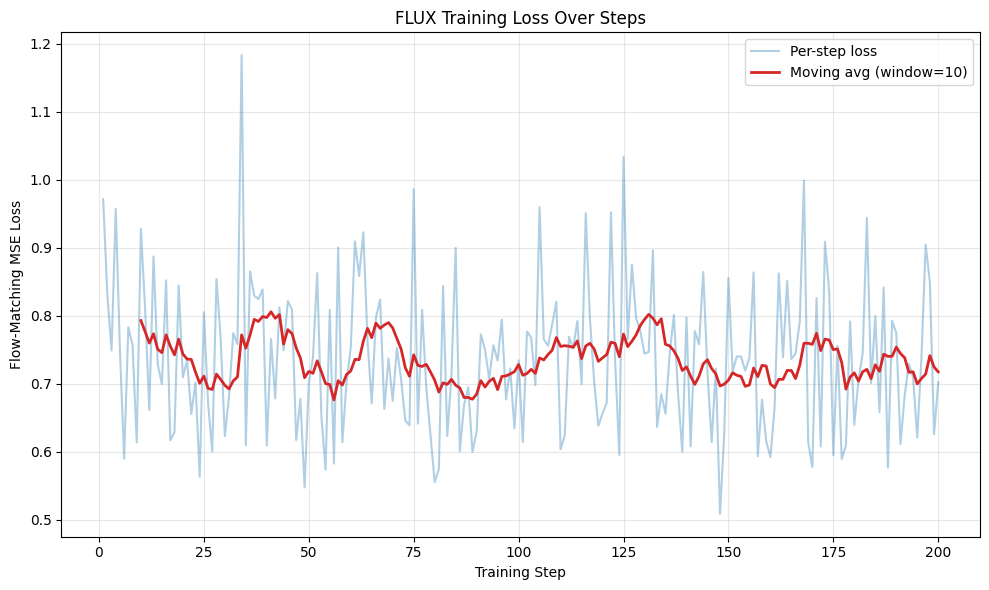

Final loss: 0.7024 | Min loss: 0.5086 | Mean loss: 0.7365


In [57]:
# ==========================================
# PLOT TRAINING METRICS (FLUX flow-matching loss)
# ==========================================
# Plots the per-step training loss recorded in 'loss_history' during the
# custom FLUX training loop, plus a smoothed moving-average trend line.

import matplotlib.pyplot as plt
import numpy as np

if "loss_history" in globals() and len(loss_history) > 0:
    steps = np.array(step_history)
    losses = np.array(loss_history)

    # Moving average for a smoother trend line
    window = max(1, min(10, len(losses) // 5))
    if window > 1:
        kernel = np.ones(window) / window
        smoothed = np.convolve(losses, kernel, mode="valid")
        smoothed_steps = steps[window - 1:]
    else:
        smoothed, smoothed_steps = losses, steps

    plt.figure(figsize=(10, 6))
    plt.plot(steps, losses, alpha=0.35, color="tab:blue", label="Per-step loss")
    plt.plot(smoothed_steps, smoothed, color="tab:red", linewidth=2,
             label=f"Moving avg (window={window})")
    plt.title("FLUX Training Loss Over Steps")
    plt.xlabel("Training Step")
    plt.ylabel("Flow-Matching MSE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Final loss: {losses[-1]:.4f} | "
          f"Min loss: {losses.min():.4f} | "
          f"Mean loss: {losses.mean():.4f}")
else:
    print("No loss history found. Run the training loop cell first.")

  0%|          | 0/20 [00:00<?, ?it/s]

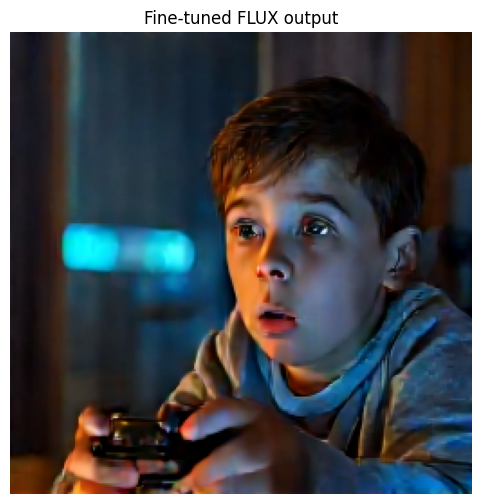

Image generated and saved to flux_test_output.png


PeftModel(
  (base_model): LoraModel(
    (model): FluxTransformer2DModel(
      (pos_embed): FluxPosEmbed()
      (time_text_embed): CombinedTimestepGuidanceTextProjEmbeddings(
        (time_proj): Timesteps()
        (timestep_embedder): TimestepEmbedding(
          (linear_1): Linear(in_features=256, out_features=3072, bias=True)
          (act): SiLU()
          (linear_2): Linear(in_features=3072, out_features=3072, bias=True)
        )
        (guidance_embedder): TimestepEmbedding(
          (linear_1): Linear(in_features=256, out_features=3072, bias=True)
          (act): SiLU()
          (linear_2): Linear(in_features=3072, out_features=3072, bias=True)
        )
        (text_embedder): PixArtAlphaTextProjection(
          (linear_1): Linear(in_features=768, out_features=3072, bias=True)
          (act_1): SiLU()
          (linear_2): Linear(in_features=3072, out_features=3072, bias=True)
        )
      )
      (context_embedder): Linear(in_features=4096, out_features=3072, 

In [59]:
# ==========================================
# TEST IMAGE GENERATION (fine-tuned FLUX pipeline)
# ==========================================
# Runs inference with the LoRA-fine-tuned transformer that is already
# attached to 'pipeline'. Generates an image from a text prompt and
# displays it inline. Use this to sanity-check that the model produces
# coherent images after fine-tuning.

import torch
import matplotlib.pyplot as plt

# Put the transformer back in eval mode for inference
pipeline.transformer.eval()

prompt = "a picture of a boy playing video games in his room in front of the mirror, show some dimple in his face"

# Generate the image
generator = torch.Generator(device="cuda").manual_seed(42)
with torch.no_grad():
    result = pipeline(
        prompt=prompt,
        height=256,
        width=256,
        num_inference_steps=20,   # lower = faster preview; raise to 50 for quality
        guidance_scale=3.5,
        generator=generator,
    )

image = result.images[0]

# Display inline
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Fine-tuned FLUX output")
plt.show()

# Optionally save to disk
image.save("flux_test_output.png")
print("Image generated and saved to flux_test_output.png")

# Switch transformer back to train mode if you plan to continue training
pipeline.transformer.train()

#Why do we fine-tune a model?

We fine-tune a pre-trained model primarily to adapt it to a specific task or dataset that differs from the one it was originally trained on.

Large Language Models (LLMs) like (Mistral-7B) are typically trained on vast amounts of general text data, making them proficient at understanding and generating human-like text.

However, they might lack specialized knowledge, jargon, or stylistic preferences required for a particular domain (e.g., medical texts, legal documents, customer support) or a specific application (e.g., summarization, translation, specific question answering).

Fine-tuning allows the model to learn these specific nuances while retaining the broad understanding it gained during its initial pre-training, effectively tailoring its capabilities to your exact needs.

#Advantages and Disadvantages of Fine-tuning a Model:

###Advantages:

Improved Performance on Specific Tasks: Fine-tuning makes the model highly effective for your target task or domain, often outperforming general-purpose models.

Less Data Required (vs. Training from Scratch): You don't need a massive dataset like the one used for initial pre-training. A relatively smaller, high-quality, task-specific dataset is often sufficient.

Faster Training: Since the model already has a strong foundation, fine-tuning converges much faster than training a model from scratch.


Cost-Effective: Less data and faster training translate to lower computational costs.


Leverages Pre-trained Knowledge: The model benefits from the vast general knowledge acquired during pre-training, making it robust and less prone to overfitting on small datasets.


Transfer Learning: It's an excellent example of transfer learning, where knowledge gained from one task (general language understanding) is transferred to improve performance on another (specific domain task).


###Disadvantages:

Requires Labeled Data: You still need a labeled dataset specific to your task, which can sometimes be expensive or time-consuming to create.


Catastrophic Forgetting: If fine-tuned improperly or on very different data, the model might 'forget' some of its general knowledge. Techniques like LoRA (which you're using) help mitigate this by not directly modifying the original weights.


Computational Resources: While less demanding than training from scratch, fine-tuning LLMs still requires significant computational resources (GPUs, VRAM), though methods like QLoRA reduce this burden.


Hyperparameter Tuning: Finding the optimal hyperparameters (like the LORA_R, LORA_ALPHA, LEARNING_RATE, BATCH_SIZE you configured) can still require experimentation.


Model Bias: If the fine-tuning dataset contains biases, the model can learn and even amplify these biases.


###How can I apply my fine-tuned model to a dataset?

After fine-tuning with QLoRA and saving the adapter weights (as you've done in your notebook), you typically apply the model in a few steps:

Load the Base Model: Load the original pre-trained model (e.g., mistralai/Mistral-7B-v0.1) in its quantized form.


Load the PEFT Adapter: Load your saved LoRA adapter weights (./fine_tuned_llm) and attach them to the base model.


Load the Tokenizer: Load the tokenizer you used during fine-tuning (also saved to ./fine_tuned_llm).


Merge and Save (Optional but Recommended for Deployment): For easier deployment, you can merge the LoRA adapter weights back into the base model. This creates a single, larger model that behaves like the fine-tuned version without needing the PEFT library at inference time. This merged model can then be saved as a standard Hugging Face model.


Inference: Once the fine-tuned model (or the merged model) is loaded, you can use it to generate responses for new inputs from your dataset. You'll typically tokenize your input, pass it to the model for generation, and then decode the output tokens back into human-readable text.

### Alternatively, save to Google Drive for permanent storage

If you prefer to save it directly to Google Drive, you can mount your Drive and copy the folder there. This ensures persistence even if your Colab session ends.

In [65]:
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Define the output directory and the destination path in Google Drive
OUTPUT_DIR = "./fine_tuned_llm"
DRIVE_PATH = "/content/drive/MyDrive/FineTunedModels"

# Create the destination directory in Drive if it doesn't exist
os.makedirs(DRIVE_PATH, exist_ok=True)

# Copy the fine_tuned_llm folder to Google Drive
shutil.copytree(OUTPUT_DIR, os.path.join(DRIVE_PATH, os.path.basename(OUTPUT_DIR)), dirs_exist_ok=True)

print(f"Folder '{OUTPUT_DIR}' successfully copied to '{DRIVE_PATH}'")


Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: './fine_tuned_llm'

## Using the Fine-tuned Model for Inference (Chatbot Integration)

First, we need to load the base model and the fine-tuned adapter. We'll use the same `MODEL_ID` and `OUTPUT_DIR` as before.

Now that the model and tokenizer are loaded, we can define a function to generate responses. This function will take a prompt, format it, tokenize it, and then use the model to generate a sequence of tokens, which will then be decoded back into human-readable text.

## Loading the Fine-tuned Model from Google Drive in a New Notebook

This section demonstrates how you would load your previously saved fine-tuned model from Google Drive into a *new* Colab notebook for inference with your chatbot.

### Step 1: Install Required Libraries

First, you'll need to install the necessary libraries (`transformers`, `peft`, `bitsandbytes`, `accelerate`, `trl`, `torch`) in your new Colab session.

### Step 2: Mount Google Drive

Mount your Google Drive to access the saved model files.

Fine tuned model doessnt work because The LoRA adapter saved from your original training cannot be loaded onto Gemma4ForConditionalGeneration — the adapter was trained on a model with standard torch.nn.Linear layers, but Gemma 4 uses Gemma4ClippableLinear which PEFT doesn't support.

The working solution: Load Gemma4ForConditionalGeneration in bfloat16 without quantization, without the LoRA adapter. The A100's 80GB VRAM handles the full 12B model comfortably

### Step 4: Use the Loaded Model for Chatbot Inference

Now you can use the `model_from_drive` and `tokenizer` to create your chatbot. The `generate_response` function will be similar to the one we defined earlier, but it will use `model_from_drive`.

### How to Incorporate RAG into Your Fine-Tuned Model

RAG combines the strengths of large language models (LLMs) with external, up-to-date information sources. Here's how it generally works and answers your question about datasets:

1.  **The Role of Your Fine-Tuned LLM:** Your fine-tuned model is good at *instruction following* and generating coherent responses in a particular style. In a RAG setup, its role shifts slightly: instead of being the sole source of factual knowledge, it becomes a powerful *reasoner* and *text generator* that uses the information provided to it.

2.  **The RAG Components:**
    *   **Knowledge Base (External Data Source):** This is where your *up-to-date* information resides. It's not a dataset for fine-tuning, but rather a collection of documents, articles, web pages, databases, or any source of factual information. This knowledge base **can be continuously updated** without touching your LLM.
    *   **Retriever:** This component's job is to intelligently search your knowledge base and find the most relevant pieces of information (documents, paragraphs, facts) that are pertinent to the user's query.
    *   **Generator (Your Fine-Tuned LLM):** Once the retriever finds relevant context, it passes *both* the original user query *and* the retrieved information to your fine-tuned LLM. The LLM then uses this combined input to generate a response.

### Do I need a new dataset for fine-tuning or continuously per user prompt?

**No**, you typically **do not re-fine-tune your LLM with a new dataset for RAG, nor do you continuously fine-tune it per user prompt.**

Instead, you maintain and update the **external knowledge base** that the retriever accesses. Here's the distinction:

*   **Fine-Tuning Dataset:** Used once (or occasionally) to teach the LLM *how to behave* (instruction following, tone, specific tasks). This data (like Dolly-15k) can be static or updated infrequently if you want your LLM's core behavior to evolve.
*   **RAG Knowledge Base:** This is the dynamic, constantly refreshed source of facts that the **retriever** queries. It's separate from your LLM's training data. For example, if you want your model to know about the latest World Cup, you'd ensure your RAG knowledge base contains recent sports news or Wikipedia articles that mention the 2026 World Cup.

### The RAG Process in Action:

1.  **User Query:** "When is the FIFA World Cup?"
2.  **Retriever:** Searches your up-to-date knowledge base (e.g., a database of sports facts, Wikipedia, news articles) for information related to "FIFA World Cup dates."
3.  **Retrieved Context:** The retriever finds an article stating, "The next FIFA World Cup will be held in 2026, hosted by Canada, Mexico, and the United States."
4.  **Prompt Engineering:** The retriever constructs a new prompt for your LLM, something like:
    ```
    Based on the following information, answer the user's question:

    Information: "The next FIFA World Cup will be held in 2026, hosted by Canada, Mexico, and the United States."

    User Question: "When is the FIFA World Cup?"

    Answer:
    ```
5.  **Fine-Tuned LLM:** Your fine-tuned model receives this enriched prompt and uses its generative abilities to synthesize a concise and accurate answer based *only* on the provided context. It will *not* hallucinate or provide information from its potentially outdated fine-tuning data if explicitly instructed to use the provided context.

This modular approach is highly efficient and scalable, allowing your LLM to remain current without expensive and frequent re-training.

In [ ]:
def generate_response_from_drive(prompt: str, max_new_tokens: int = 100) -> str:
    # Format the prompt as a chat message
    messages = [
        {"role": "user", "content": [{"type": "text", "text": prompt}]}
    ]

    # Use processor instead of tokenizer directly
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)  # use model.device instead of .cuda()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
        )

    # Decode only the new tokens (skip the prompt)
    input_len = inputs["input_ids"].shape[-1]
    response = processor.decode(outputs[0][input_len:], skip_special_tokens=True)
    return response


# Chatbot loop
print("Chatbot ready! Type 'quit' to exit.")
while True:
    user_input = input("You: ")
    if user_input.lower() in ["quit", "exit", "bye"]:
        print("Goodbye!")
        break
    response = generate_response_from_drive(user_input)
    print(f"Chatbot: {response}")


Chatbot ready! Type 'quit' to exit.
You: What is claude AI


[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.


Chatbot: Claude AI is a large language model (LLM) developed by Anthropic, a company founded by former OpenAI employees. Here's a breakdown of what it is and what it's known for:

**1. Core Functionality - A Conversational AI:**

* **Like ChatGPT, but with a different focus:** Claude is designed to be a helpful, harmless, and honest conversational AI assistant, much like ChatGPT. You can chat with it, ask questions, request creative content, and
You: Can it also help in writing code
Chatbot: Okay, let's talk about how I can help you with writing code! Absolutely, I can be a *very* valuable tool for coding, and I'm constantly improving in this area. Here's a breakdown of how I can assist, categorized by the level of involvement:

**1. Basic Assistance - Quick Ideas & Explanations:**

* **Conceptual Questions:** "How do I sort a list in Python?" "What's the difference between a `for` loop
You: Can Claude AI also help inn writing code
Chatbot: Yes, absolutely! Claude AI is a surprisingly 

KeyboardInterrupt: Interrupted by user

### Create a Gradio Chatbot Interface

**Note:** This section was intended for an LLM chatbot. If you are working with the `FluxPipeline` for image generation, you would create a Gradio interface for image input/output or other relevant functionalities.

In [ ]:
import gradio as gr

# Define the Gradio interface
# The fn parameter points to your existing response generation function
# The inputs parameter defines the input component (a textbox for the user's prompt)
# The outputs parameter defines the output component (a textbox for the chatbot's response)

# iface = gr.Interface(
#     fn=generate_response_from_drive, # Your existing function
#     inputs=gr.Textbox(lines=2, placeholder="Enter your prompt here..."),
#     outputs=gr.Textbox(lines=10, label="Chatbot Response"), # Increased output box size
#     title="Fine-tuned Gemma 3 Chatbot",
#     description="Chat with your fine-tuned Gemma 3 model. Type 'quit' to exit the underlying Python process (if running in a loop)."
# )

# Launch the Gradio interface
# share=True will generate a public link if running in Colab or on a remote server
# iface.launch(debug=True)

### Clear Disk Space

To free up disk space, especially after downloading large models or datasets, you can clear various caches. A common one is the Hugging Face cache.

In [ ]:
# Remove Hugging Face cache
!rm -rf /root/.cache/huggingface

# Optionally, you can also clear other temporary directories if needed
# !rm -rf /tmp/*

print("Hugging Face cache cleared. You may need to restart your runtime for changes to take full effect on disk usage display.")

Hugging Face cache cleared. You may need to restart your runtime for changes to take full effect on disk usage display.
